In [119]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Text(0, 0.5, 'Mileage (Km)')

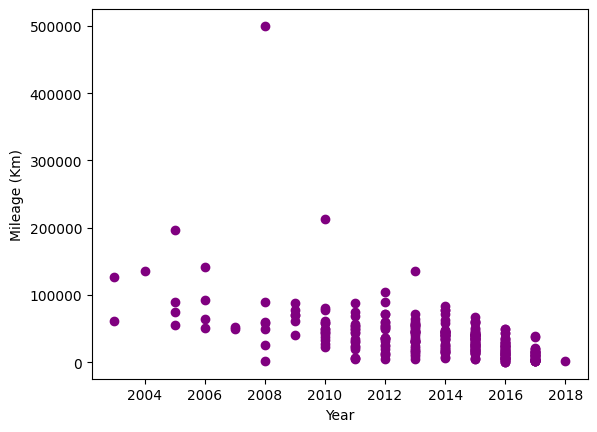

In [100]:
vehicle_data = pd.read_csv(r"C:\Users\Rebecca\Desktop\Python Projects\GitHub - Vehicle Data\car data.csv")
display(vehicle_data.head())

plt.scatter(vehicle_data['Year'], vehicle_data['Kms_Driven'], color='purple')
plt.xlabel('Year')
plt.ylabel('Mileage (Km)')

Model beta:  -7051.580967568475
Model intercept:  14236207.43058202
R^2 score:  0.2749345756409639
RMSE:  33057.432567821576


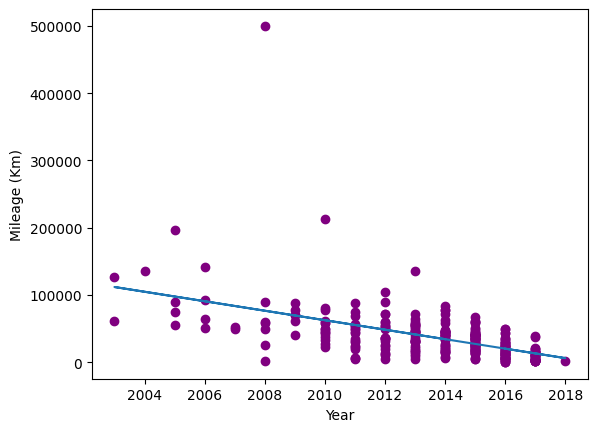

In [117]:
X = vehicle_data[['Year']].values.reshape(-1,1)
y = vehicle_data[['Kms_Driven']]
model = LinearRegression()
model.fit(X,y)

predicted = [model.predict([[vehicle_data['Year'][i]]])[0][0] for i in range(len(vehicle_data))]
years = [vehicle_data['Year'][i] for i in range (0, len(vehicle_data['Year']))]
prediction_data = pd.DataFrame({'Year':years, 'Predicted Values':predicted})
plt.plot(prediction_data['Year'], prediction_data['Predicted Values'])
plt.scatter(vehicle_data['Year'], vehicle_data['Kms_Driven'], color='purple')
plt.xlabel('Year')
plt.ylabel('Mileage (Km)')

#Inspecting the model 
print("Model beta: ", model.coef_[0][0])
print("Model intercept: ", model.intercept_[0])
print("R^2 score: ", r2_score(y, model.predict(X)))
print("RMSE: ", np.sqrt(mean_squared_error(y, model.predict(X))))

#The main issue from this model arise in how the data is set up
#    Having an intercept of 14,000,000 Km is unrealistic, since no car has that much mileage before being written off, but not only this, in the year 0,
#    there were no cars! The way this model should be improved is looking at data from when cars were first made (or just after), I reckon this would
#    show a non-linear relationship. However for the data we have, I think it is safe to assume linearity for this time period. Extrapolation would not 
#    be suitable for this model.
#    These cars would have been sampled in 2018 when the new cars were made, if we were to extrapolate to 2020, we would expect the car to be at low mileage
#    However this model would no long stand since the 2018 cars would have aged, we could predict how they age, but it means that particularly this data
#    Is not suitable for modelling future predictions, and also only for model short term backwards-interpolation


So how did this work? <br>
We have X our data, which I had simply modelled as the year, however we can have multiple dimensions of X if we wanted, all important factors of the mileage we may predict in our car, the more beta parameters we have, only if the are no-redundant, the more accurate our model may be for predicting mileage. Other important factors may include; <br>
1. Type of engine
2. Model of car
3. Transmission
4. Fuel type <br>

just from this dataset, however if we had the category of insurance, such as if it has had a write off, or broken down, or incidents relating to the function of the car, this may also affect it. <br>

So we have X, our year, and we have $y$ our observations of mileage, but we do not have $\beta$, which is what we are predicting. <br>
So we use the linear regression model, which uses the normal equation: <br>
$ J(\beta) = 1/n \sum_{i=1}^n (y_i - \hat{y}_i)^2 $ <br>
Which we can minimise to find $\beta$, or in algebraic terms, we write: <br>
$ \beta = (X^{T}X)^{-1}X^{T}y $ <br>
or in contextual terms: <br>
$ \beta = (Year^{T}Year)^{-1}Year^{T}Mileage_{observed} $ <br>
Which $Year^T$ is the same as writing Year as a row vector, and in an unsolved form: <br>
$Mileage_{observed} = \beta *Year + \epsilon$

301


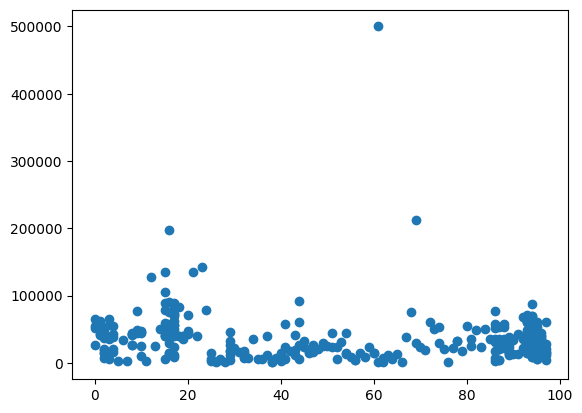

In [107]:
#Using more than one beta parameter
#Since the rest of the parameters are categorical, we need to create new columns to fit them to the model 
vehicle_data['Car_Name_Key'] = pd.factorize(vehicle_data['Car_Name'])[0]
vehicle_data['Transmission_Key'] = pd.factorize(vehicle_data['Transmission'])[0]
vehicle_data['Fuel_Type_Key'] = pd.factorize(vehicle_data['Fuel_Type'])[0]
vehicle_data['Seller_Type_Key'] = pd.factorize(vehicle_data['Seller_Type'])[0]
vehicle_data
print(len(vehicle_data))
#Plotting to see if any have correlation
plt.scatter(vehicle_data['Car_Name_Key'], vehicle_data['Kms_Driven'])

In [ ]:
X_2 = vehicle_data[['Year', 'Transmission_Key', 'Fuel_Type_Key', 'Seller_Type_Key']]
y_2 = vehicle_data[['Kms_Driven']]

model_2 = LinearRegression()
model_2.fit(X_2, y_2)
model_2.predict(X_2)

#Inspecting the model 
print("Model beta: ", model_2.coef_[0][0])
print("Model intercept: ", model_2.intercept_[0])
print("R^2 score: ", r2_score(y_2, model_2.predict(X_2)))
print("RMSE: ", np.sqrt(mean_squared_error(y_2, model_2.predict(X_2))))
#Thus our second model with more beta, has a higher R^2 score, which means it is more closely fit to our model, it explains 34% of the variance, rather
#than 27%, in addition our RMSE is lower which we ideally want, the data has a lot of variation, so I would not expect this to be lower than 2000

Model beta:  -7199.135814624517
Model intercept:  14529522.541215898
R^2 score:  0.3373774376884222
RMSE:  31601.931880886772


In [ ]:
#A better way to predict data is through testing and training, so lets split our data a bit better
X_train, X_test, y_train, y_test = train_test_split(X_2, y_2, test_size=0.2)
model_2.fit(X_train, y_train)
model_2.predict(X_test)
#And now we can get a better look into the R score and the RMSE 
print("Model beta: ", model_2.coef_[0][0])
print("Model intercept: ", model_2.intercept_[0])
print("R^2 score: ", r2_score(y_test, model_2.predict(X_test)))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, model_2.predict(X_test)))) 
#The RMSE is actually a lot lower which is strange but good!
#The reason the RMSE is lower, may be because we picked up outliers in our training sample not the testing sample, if we were to do this in real life,
#we would exclude outliers from this investigation, of course there are outliers which are real-world existences, but they are UNLIKELY, and that
#is the main point, we cannot predict properly with unlikely situations!

Model beta:  -7925.031636666135
Model intercept:  15990887.986146744
R^2 score:  0.30182615880665953
RMSE:  18161.89728809109
